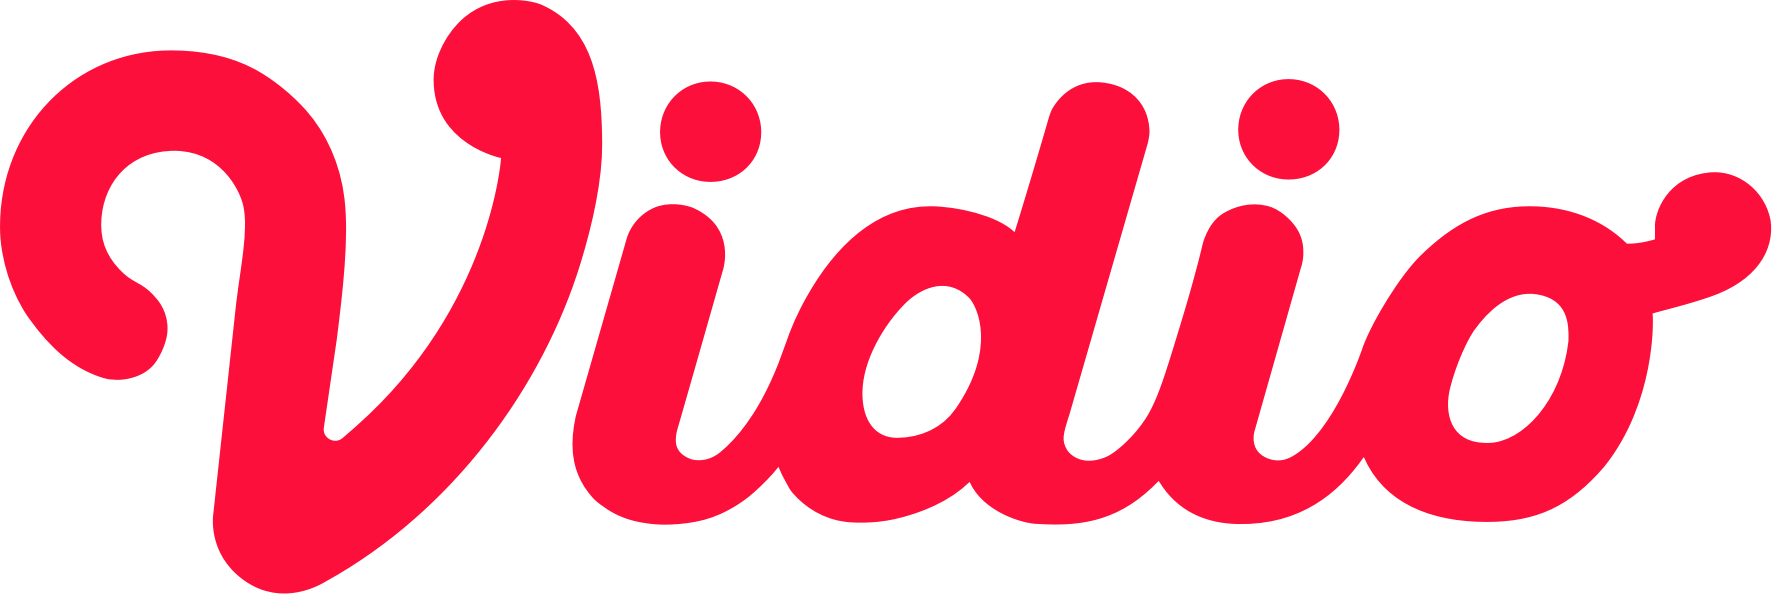

In [1]:
from IPython.display import Image 

Image("Gambar/vidio-hero-logo-light.png")

<center><h1>Data Analyst Study Case</h1></center>

This is an EDA (Exploratory Data Analytics) for plays dataset which contains 15 days of overall plays activity from users on Vidio. Due to limitations, the dataset used is the 1%. Mostly, EDA is consisted of things like description of data, handling missing data/values, handling outliers, and understanding relationships and new insights through plots. First, let's import the basic libraries often used in EDA. We can still import libraries as the process is running later.



In [2]:
import pandas as pd
import numpy as np
import math
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

After importing libraries, the dataset must be 'loaded' into the notebook. Usually, the name is not dataset anymore and become dataframe.

In [3]:
df = pd.read_csv('part-00000-0dd5f001-57d7-4ec1-a3f0-53ea28bba9c3-c000.csv',error_bad_lines=False) 
df.head()

b'Skipping line 23509: expected 41 fields, saw 43\n'
b'Skipping line 36946: expected 41 fields, saw 42\nSkipping line 43788: expected 41 fields, saw 42\nSkipping line 45437: expected 41 fields, saw 49\n'
b'Skipping line 52141: expected 41 fields, saw 42\n'
b'Skipping line 73470: expected 41 fields, saw 42\nSkipping line 75103: expected 41 fields, saw 42\n'
b'Skipping line 87928: expected 41 fields, saw 42\n'
b'Skipping line 98453: expected 41 fields, saw 42\nSkipping line 98771: expected 41 fields, saw 42\nSkipping line 101047: expected 41 fields, saw 42\nSkipping line 104676: expected 41 fields, saw 42\n'
C:\ProgramData\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3071: DtypeWarning: Columns (20) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,hash_content_id,hash_play_id,hash_visit_id,hash_watcher_id,hash_film_id,hash_event_id,is_login,playback_location,platform,play_time,...,app_version,city,play_duration,content_type,stream_type,title,category_name,film_title,season_name,genre_name
0,0096dafb1049ee942e8e7cbad5abf4a46dc92e3995caac...,0162f124f5bd61592d9bca6aaa3b1b6097a00b62ef33c9...,27dfffe2bb74f8767caeb64ac4c92e9eaf4b11a28ef7e1...,e7c2138fd9d4047356066a01de46fc22ee9955a6fd6679...,NaN,c81bd64a212d3b5cb227499a6b4a3dc607748ae5133e48...,False,embed,web-mobile,2020-02-02T10:21:20.000Z,...,NaN,NaN,0,vod,NaN,Kiprah Eks Pemain Juventus yang Dikaitkan deng...,Sports,NaN,NaN,NaN
1,01ddda2f8667719625bd0afa58537fd95a166c93233b8b...,5f6c722782c919a9cb6254e94086462a6c34794dc741b6...,90b2b454e70a2c13cf9e8ca987d7c4f914c7d819532c5d...,d265ea2b8df584c51de3b2c6aebb6a0415384a18d1a148...,NaN,90a514e451e400c4c32ac42815920a66c500c1c2ea347d...,False,embed,web-mobile,2020-02-02T12:17:33.000Z,...,NaN,NaN,19,vod,NaN,"Pindah ke Inter Milan, Christian Eriksen Jadi ...",Sports,NaN,NaN,NaN
2,01ddda2f8667719625bd0afa58537fd95a166c93233b8b...,66c32aa6aa6a63f7d85d1bd1b8b6b295477c88794888d8...,f79cab25855841a83e6aa01eccbf3d167491a868977b77...,d2585a4b468b7cdbebc053ffc5b49cebd58d6e738bccdd...,NaN,c278001db02102ece22d428b9235332856cba4754b63a0...,False,embed,web-mobile,2020-02-02T01:26:42.000Z,...,NaN,NaN,24,vod,NaN,"Pindah ke Inter Milan, Christian Eriksen Jadi ...",Sports,NaN,NaN,NaN
3,01e34cb2658d0461f220bda493cb38427eef7de1e23e6e...,38976454aec1c7ff4ca0a35df8821db29227443352e705...,f23800acfeede429803cb2a1380ca7652067fb35d079a8...,bba3183af4f6c29d97dce6ee557561e3feef31d19ae9ab...,NaN,ed0731e9861306e6e26cf3cfb5a43da6b0e19af3ff3ff5...,False,embed,web-mobile,2020-02-02T13:45:05.000Z,...,NaN,NaN,0,vod,NaN,5 Kelebihan Mikel Arteta Menurut Pep Guardiola,Sports,NaN,NaN,NaN
4,01e34cb2658d0461f220bda493cb38427eef7de1e23e6e...,4b4ee4aa4c37519250aa6efbd78e789b40d976474a1c37...,b058895b6fce58bcfbd72bfd7a3dfa4ae01d094e21c976...,317ecdb779c3ba5bdc1818405aaafebcef35e9582c42e5...,NaN,3679f65950032d6bff1323df5b29292adad99918d616ae...,False,embed,web-desktop,2020-02-02T13:23:40.000Z,...,NaN,NaN,4,vod,NaN,5 Kelebihan Mikel Arteta Menurut Pep Guardiola,Sports,NaN,NaN,NaN


This dataset seems to be unlike any other dataset I've worked before. For example, I need to add command for skipping badlines in the dataset, so it can read it without errors. The dataframe can't be loaded when there's error. I assumed the dataset would still worked without the bad lines considering it size, so I just skipped it and not using the rows with the bad lines.  

In [4]:
df.shape

(106811, 41)

Command above means this dataframe have 106811 rows and 41 columns. This, of course, also counting all of the missing value. The command below shows each of column names, sorted from the left.

In [5]:
df.columns

Index(['hash_content_id', 'hash_play_id', 'hash_visit_id', 'hash_watcher_id',
       'hash_film_id', 'hash_event_id', 'is_login', 'playback_location',
       'platform', 'play_time', 'end_time', 'referrer', 'average_bitrate',
       'bitrate_range', 'total_bytes', 'buffer_duration', 'referrer_group',
       'completed', 'utm_source', 'utm_medium', 'utm_campaign', 'player_name',
       'has_ad', 'flash_version', 'os_name', 'os_version', 'browser_name',
       'browser_version', 'app_name', 'autoplay', 'is_premium', 'app_version',
       'city', 'play_duration', 'content_type', 'stream_type', 'title',
       'category_name', 'film_title', 'season_name', 'genre_name'],
      dtype='object')

Next is, we check for each column using info() command. This command will show several information related to the dataframe. For example, the name of each column, their non-null count, and the data type for each column. 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106811 entries, 0 to 106810
Data columns (total 41 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   hash_content_id    106811 non-null  object 
 1   hash_play_id       106811 non-null  object 
 2   hash_visit_id      106811 non-null  object 
 3   hash_watcher_id    106811 non-null  object 
 4   hash_film_id       5818 non-null    object 
 5   hash_event_id      106811 non-null  object 
 6   is_login           106811 non-null  bool   
 7   playback_location  106811 non-null  object 
 8   platform           106811 non-null  object 
 9   play_time          106811 non-null  object 
 10  end_time           106811 non-null  object 
 11  referrer           101050 non-null  object 
 12  average_bitrate    101865 non-null  float64
 13  bitrate_range      106811 non-null  object 
 14  total_bytes        106811 non-null  int64  
 15  buffer_duration    106811 non-null  float64
 16  re

We can see from above, the dataset have 3 boolean columns, 3 float columns, 2 int columns, and 33 object columns. Object data type also can be called string data type. Remember before the dataframe have 106811 rows? If the non null count is not the same as that value, then there are missing values in that column. We will elaborate it further later, for now we check the dataframe with the describe() command.

In [7]:
df.describe()

,average_bitrate,total_bytes,buffer_duration,city,play_duration
count,101865.000000,1.068110e+05,1.068110e+05,0.0,106811.000000
mean,199406.240230,7.765342e+07,2.272422e+05,NaN,425.431847
std,141397.648432,4.683612e+08,7.416347e+07,NaN,1541.638614
min,144.000000,0.000000e+00,0.000000e+00,NaN,0.000000
25%,633.000000,7.500000e+02,0.000000e+00,NaN,4.000000
50%,300000.000000,5.062500e+05,1.000000e+00,NaN,41.000000
75%,300000.000000,1.125000e+07,6.000000e+00,NaN,120.000000
max,300000.000000,3.092062e+10,2.423807e+10,NaN,82455.000000


Describe is basically describing the correspondent column in statistical manners. This includes the count, mean, standard deviation (std), minimum value, the quartiles, and maximum value. By default, because describe is statistical, it only includes the column with number data type. We can change the command to include all other column, but I don't think it's necessary in this case.  

We can see from info and describe there are several columns with missing value. There are many reasons for missing data. For example, user did not want to fill data due to privacy issues. There are other reasons too. Loss of data while transferring or insufficient information to fill a particular column is also a common reason. Now we will check for column with null values.

In [8]:
df.isnull().values.any()

True

This command just check the obvious, what we already know several seconds ago. That there is null or missing value in the dataset. This command, however, at least helps when the analyst is not careful enough reading the numbers before. The command below will count each of the column missing values.  

In [9]:
df.isnull().sum()

hash_content_id           0
hash_play_id              0
hash_visit_id             0
hash_watcher_id           0
hash_film_id         100993
hash_event_id             0
is_login                  0
playback_location         0
platform                  0
play_time                 0
end_time                  0
referrer               5761
average_bitrate        4946
bitrate_range             0
total_bytes               0
buffer_duration           0
referrer_group            0
completed             38937
utm_source           106724
utm_medium           106724
utm_campaign         106773
player_name            3267
has_ad                    0
flash_version         34850
os_name               33725
os_version              405
browser_name          33666
browser_version       36038
app_name                  0
autoplay              38960
is_premium                0
app_version           72129
city                 106811
play_duration             0
content_type              0
stream_type         

From this command, we can see how many columns and the nummber of missing values. We can see several columns like hash_film_id,  referrer, average_bitrate, completed, utm_source, utm_medium, utm_campaign, player_name, flash_version, os_name, os_version, browser_name, browser_version, autoplay, app_version, city, stream_type, category_name, film_title, season_name and genre_name all have missing value. There are several columns which have a lot of missing values. Those columns also mostly have object data type, so I think it's better to just drop them.           

In [24]:
df = df.drop(columns = 'city', axis = 1)

In [37]:
df = df.drop(['hash_film_id', 'utm_source', 'utm_medium', 'utm_campaign','film_title', 'season_name', 'genre_name'], axis = 1) 

Command above is for dropping columns. The first one is for dropping a single column, while the second is for multiple columns. All the columns that dropped have around 100000 missing values. For the other columns with missing values, if they can't be replaced then it's simply faster to drop them. However, I think the overall objective of this study case is to explore and analyze, thus, some columns probably will have information for later. After this I will check several columns which I suspect have duplicate value in them.

In [10]:
df.duplicated(subset=['referrer']).any()

True

In [15]:
df.duplicated(subset=['hash_play_id']).any()

False

In [14]:
df.duplicated(subset=['hash_content_id']).any()

True

In [16]:
df.duplicated(subset=[ 'hash_visit_id']).any()

True

In [17]:
df.duplicated(subset= ['hash_watcher_id']).any()

True

In [18]:
df.duplicated(subset=['hash_event_id']).any()

False

In [12]:
df.duplicated(subset=['hash_film_id']).any()

True

In [13]:
df.duplicated(subset=['bitrate_range']).any()

True

In [41]:
df.duplicated(subset=['title']).any()

True

Unsurprisingly, there are some columns with duplicated values. There's also columns with unique values. This actually will contribute in later insight (or question 2 if you will). The last thing to do before wrapping question 1 and move to graph analyzing for question 2, is checking the correlation for the dataset. The rule of thumb is correlation can only be calculated with number data type. The command will automatically choose the column with number data type and calculate the correlations.

In [25]:
df.corr()

,is_login,average_bitrate,total_bytes,buffer_duration,has_ad,is_premium,play_duration
is_login,1.000000,0.319692,0.101245,-0.001672,-0.231610,0.167211,0.158977
average_bitrate,0.319692,1.000000,0.120405,0.002231,-0.105269,0.053275,0.069359
total_bytes,0.101245,0.120405,1.000000,0.002588,-0.154921,0.012104,0.812459
buffer_duration,-0.001672,0.002231,0.002588,1.000000,-0.005586,-0.000286,0.001663
has_ad,-0.231610,-0.105269,-0.154921,-0.005586,1.000000,-0.168976,-0.129162
is_premium,0.167211,0.053275,0.012104,-0.000286,-0.168976,1.000000,0.062105
play_duration,0.158977,0.069359,0.812459,0.001663,-0.129162,0.062105,1.000000


I have known some method for easier reading the correlation value. The function below is just for changing the text color. If it's positive then the text's color is black. If negative, it's red. However, don't assume that the negative value means auto dropping the column (if it's used for modelling). Correlation actually have positive and negative influences. If the correlation value is positive, then they affect each other positively, for example when a column's value is up then the other is also rising. And vice versa. For the negative values it's the opposite. If one is rising, the the other will fall (heheh). It's a good mindset to check which column has positive or negative impact towards the target column.

In [26]:
def color_negative_red(val):
    color = 'red' if val < 0 else 'black'
    return 'color: %s' % color

In [27]:
df.corr().style.applymap(color_negative_red)

,is_login,average_bitrate,total_bytes,buffer_duration,has_ad,is_premium,play_duration
is_login,1.000000,0.319692,0.101245,-0.001672,-0.231610,0.167211,0.158977
average_bitrate,0.319692,1.000000,0.120405,0.002231,-0.105269,0.053275,0.069359
total_bytes,0.101245,0.120405,1.000000,0.002588,-0.154921,0.012104,0.812459
buffer_duration,-0.001672,0.002231,0.002588,1.000000,-0.005586,-0.000286,0.001663
has_ad,-0.231610,-0.105269,-0.154921,-0.005586,1.000000,-0.168976,-0.129162
is_premium,0.167211,0.053275,0.012104,-0.000286,-0.168976,1.000000,0.062105
play_duration,0.158977,0.069359,0.812459,0.001663,-0.129162,0.062105,1.000000


Lastly for this question, is how to show the heatmap. The heatmapn is basically used for visualizing the correlation again, but with more flair. Heatmap is one of the prominent graph for Seaborn libraries. The other graph and in depth analysis for remaining columns will go to question 2, along with the usage of Tableau.

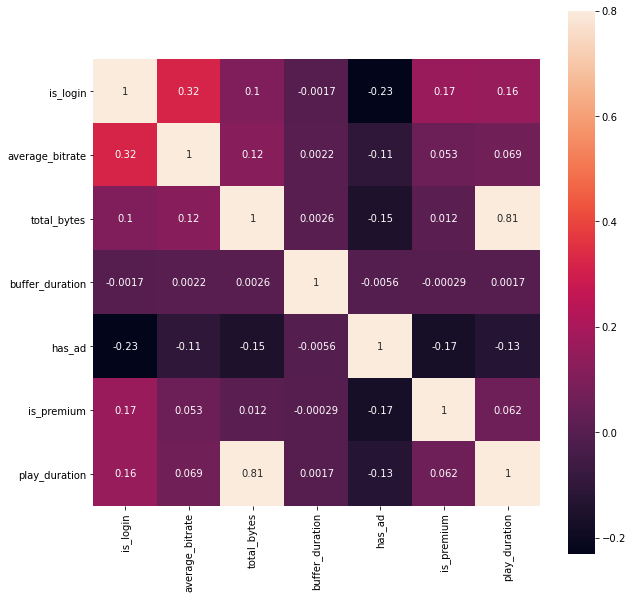

In [30]:
C_mat = df.corr()
fig = plt.figure(figsize = (10,10))

sns.heatmap(C_mat, vmax = .8, square = True,annot = True)
plt.show()

In [39]:
#df_longest_play_dur_watcher = df[((df.hash_watcher_id == 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855') )]

In [40]:
#df_longest_play_dur_watcher.to_csv(r'longest_play_watcher.csv', index = False)